# Module 15 – Mini Assessment

This assessment covers the basic concepts of Exploratory Data Analysis (EDA) and practical EDA tasks.

## Part 1 – Conceptual Questions

### 1. What is EDA?

EDA (Exploratory Data Analysis) is the process of understanding a dataset using statistics, visualizations, and basic analysis before building a machine learning model.

### 2. Why is EDA performed before Machine Learning?

EDA helps us understand the data and identify missing values, duplicates, outliers, patterns, and relationships before building a model.

### 3. What is the difference between univariate, bivariate, and multivariate analysis?

Univariate analysis studies one variable.

Bivariate analysis studies two variables.

Multivariate analysis studies more than two variables.

### 4. How do you identify missing values?

Missing values can be identified using `isnull()` or `isna()` in Pandas.

### 5. How do you identify duplicate records?

Duplicate records can be identified using the `duplicated()` function.

### 6. What is an outlier?

An outlier is a value that is unusually high or low compared with the other values in the dataset.

### 7. Explain the IQR method.

IQR stands for Interquartile Range. It is calculated using the difference between Q3 and Q1. Values outside the IQR limits are considered possible outliers.

### 8. What is skewness?

Skewness shows whether a numerical distribution is balanced or has a longer tail on one side.

### 9. What is correlation?

Correlation shows the strength and direction of the relationship between two numerical variables.

### 10. What is the difference between correlation and causation?

Correlation means two variables are related, while causation means a change in one variable directly causes a change in another variable.

### 11. What is multicollinearity?

Multicollinearity occurs when two or more independent features are highly related to each other.

### 12. How do you identify class imbalance?

Class imbalance can be identified by checking the number and percentage of records in each target class.

### 13. Why should outliers not always be removed?

Some outliers may represent real and important observations. Removing them without understanding them can result in loss of useful information.

## Part 2 – Coding Exercises

### 1. Load the dataset and inspect its basic information.

### 2. Check for missing values.

### 3. Check for duplicate records.

### 4. Identify numerical and categorical features.

### 5. Create a correlation heatmap.

### 6. Detect outliers using the IQR method.

### 7. Analyze the distribution of a numerical feature.

### 8. Perform categorical analysis.


### 1. Load the dataset and inspect its basic information.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/hotel_bookings.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### 2. Check for missing values.

In [5]:
print("Missing Values:")
display(df.isnull().sum())

Missing Values:


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         


### 3. Check for duplicate records.

In [6]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 31994


### 4. Identify numerical and categorical features.

In [7]:
numerical_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numerical Features:")
print(numerical_cols.tolist())

print("\nCategorical Features:")
print(categorical_cols.tolist())

Numerical Features:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\HP\AppData\Local\Temp\ipykernel_22196\2164064662.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


### 5. Create a correlation heatmap.


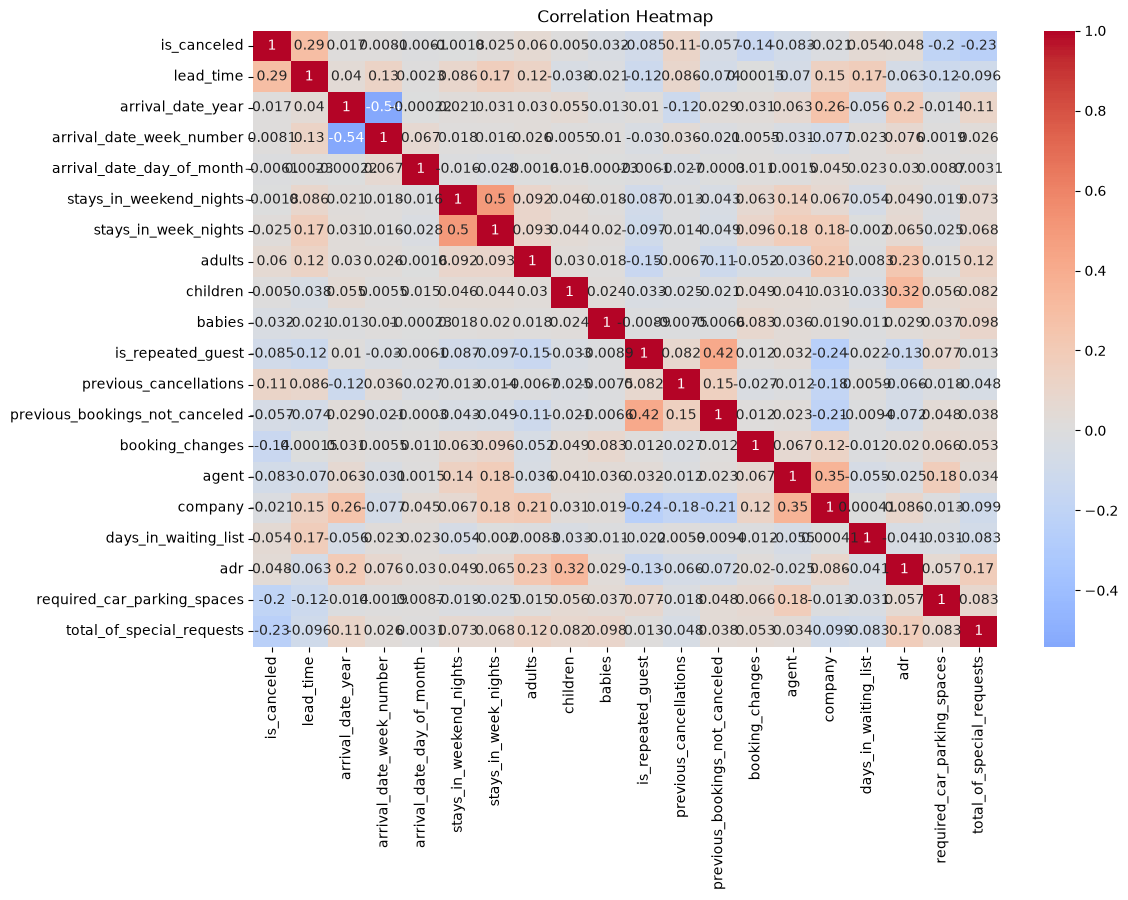

In [8]:
correlation = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### 6. Detect outliers using the IQR method.

In [9]:
num_df = df.select_dtypes(include="number")

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((num_df < Q1 - 1.5 * IQR) |
            (num_df > Q3 + 1.5 * IQR)).sum()

display(outliers.sort_values(ascending=False))

adults                            29710
booking_changes                   18076
children                           8590
required_car_parking_spaces        7416
previous_cancellations             6484
is_repeated_guest                  3810
adr                                3793
days_in_waiting_list               3698
previous_bookings_not_canceled     3620
stays_in_week_nights               3354
lead_time                          3005
total_of_special_requests          2877
babies                              917
stays_in_weekend_nights             265
is_canceled                           0
arrival_date_year                     0
arrival_date_week_number              0
arrival_date_day_of_month             0
company                               0
agent                                 0
dtype: int64

### 7. Analyze the distribution of a numerical feature.

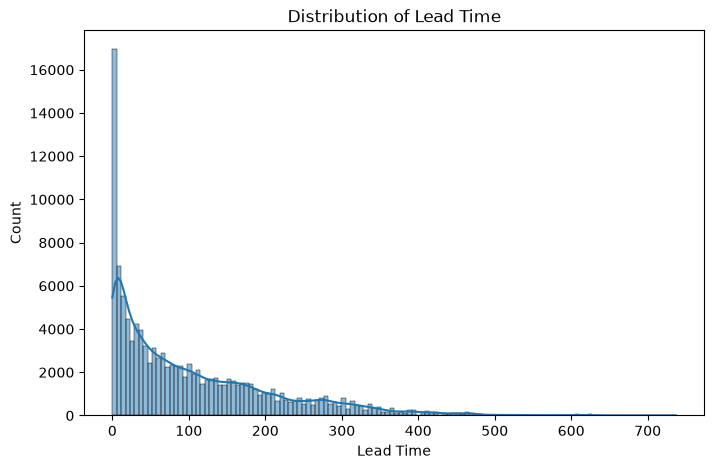

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(df["lead_time"], kde=True)

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time")
plt.ylabel("Count")
plt.show()

### 8. Perform categorical analysis.

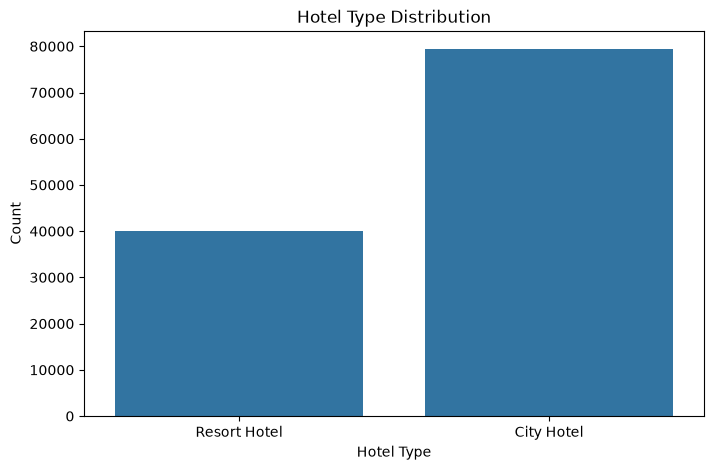

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="hotel")

plt.title("Hotel Type Distribution")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.show()

## EDA Summary

Write the main findings from the analysis, including important patterns, relationships, data quality issues, and observations from the visualizations.